<a href="https://colab.research.google.com/github/xwx-codingweb/XIA_DSPN_S26/blob/master/ExerciseSubmissions/13_resampling-methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, make a new dataframe `d1` that only inclues the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [11]:
# WRITE YOUR CODE HERE
library(tidyverse)

data <- read.csv("https://raw.githubusercontent.com/xwx-codingweb/XIA_DSPN_S26/master/Exercise%20datasets/hcp_data/unrestricted_trimmed_1_7_2020_10_50_44.csv")

head(data)

d1 <- dat %>%
  select(Subject, Gender, Flanker_Unadj,
         FS_IntraCranial_Vol,
         FS_Tot_WM_Vol,
         FS_Total_GM_Vol) %>%
  drop_na()

head(d1)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


,Subject,Release,Acquisition,Gender,Age,MMSE_Score,PSQI_Score,PSQI_Comp1,PSQI_Comp2,PSQI_Comp3,⋯,Noise_Comp,Odor_Unadj,Odor_AgeAdj,PainIntens_RawScore,PainInterf_Tscore,Taste_Unadj,Taste_AgeAdj,Mars_Log_Score,Mars_Errs,Mars_Final
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,100004,S900,Q06,M,22-25,29,8,1,2,2,⋯,5.2,101.12,86.45,2,45.9,107.17,105.31,1.80,0,1.80
2,100206,S900,Q11,M,26-30,30,6,1,1,1,⋯,6.0,108.79,97.19,1,49.7,72.63,72.03,1.84,0,1.84
3,100307,Q1,Q01,F,26-30,29,4,1,0,1,⋯,3.6,101.12,86.45,0,38.6,71.69,71.76,1.76,0,1.76
4,100408,Q3,Q03,M,31-35,30,4,1,1,0,⋯,2.0,108.79,98.04,2,52.6,114.01,113.59,1.76,2,1.68
5,100610,S900,Q08,M,26-30,30,4,1,1,0,⋯,2.0,122.25,110.45,0,38.6,84.84,85.31,1.92,1,1.88
6,101006,S500,Q06,F,31-35,28,2,1,1,0,⋯,6.0,122.25,111.41,0,38.6,123.80,123.31,1.80,0,1.80


,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
1,100206,M,130.42,1864518,543134,807245
2,100307,F,112.56,1512540,407292,664124
3,100408,M,121.18,1684117,500417,726206
4,100610,M,126.53,1816044,512946,762308
5,101006,F,101.85,1437868,429449,579632
6,101107,M,107.04,1512727,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

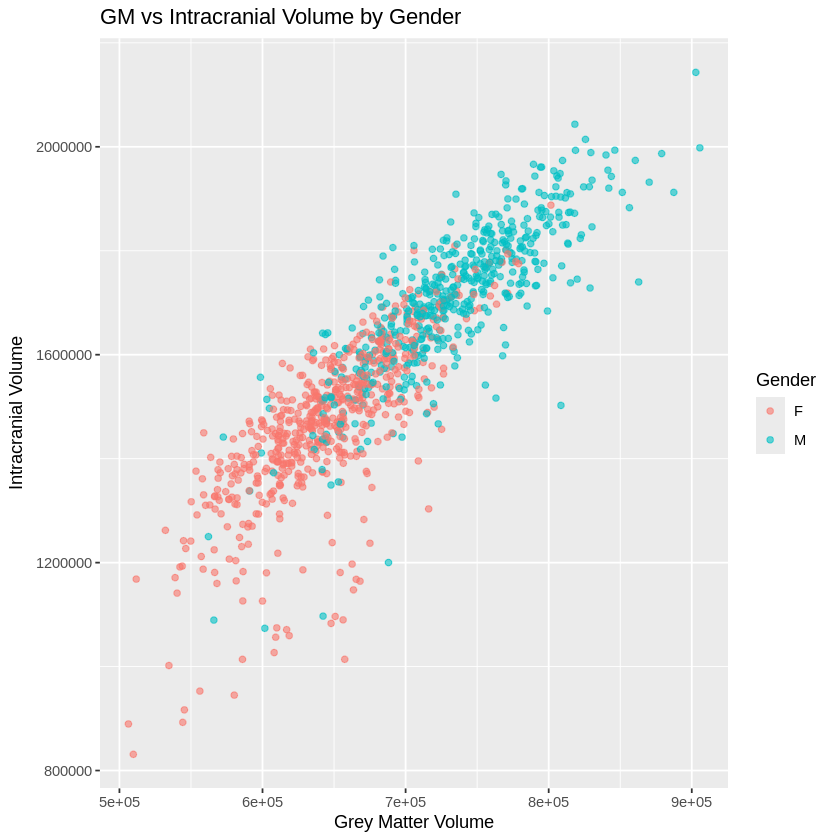

In [12]:
# WRITE YOUR CODE HERE
ggplot(d1, aes(x = FS_Total_GM_Vol,
               y = FS_IntraCranial_Vol,
               color = Gender)) +
  geom_point(alpha = 0.6) +
  labs(
    x = "Grey Matter Volume",
    y = "Intracranial Volume",
    title = "GM vs Intracranial Volume by Gender"
  )

What patterns do you observe in the scatter plot?

> There is a strong positive relationship between grey matter volume and intracranial volume.

> The points appear to cluster by gender, suggesting that males and females tend to differ in overall brain volume measures, with males generally having larger volumes.

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logisic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [15]:
# WRITE YOUR CODE HERE
d1$Gender <- as.factor(d1$Gender)

model <- glm(Gender ~ FS_Tot_WM_Vol +
                        FS_Total_GM_Vol +
                        FS_IntraCranial_Vol,
             data = d1,
             family = binomial)

summary(model)


Call:
glm(formula = Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
    family = binomial, data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.262e+01  1.347e+00 -16.787  < 2e-16 ***
FS_Tot_WM_Vol        2.140e-06  3.059e-06   0.699    0.484    
FS_Total_GM_Vol      1.959e-05  3.145e-06   6.229 4.70e-10 ***
FS_IntraCranial_Vol  5.020e-06  1.177e-06   4.263 2.01e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are signficantly associated with gender?

> Intracranial volume and grey matter volume are typically significant predictors of gender, while white matter volume is not significant.

> Overall, brain volume measures are strongly associated with gender.

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [17]:
# WRITE YOUR CODE HERE
# predicted probabilities
probs <- predict(model, type = "response")

# classify
pred_class <- ifelse(probs > 0.5, "M", "F")

# accuracy
accuracy <- mean(pred_class == d1$Gender)

accuracy


[1] 0.8203055

What is the prediction accuracy for gender from the full model?

> The training accuracy of the model is approximately 82%, indicating that brain volume measures provide a reasonably good prediction of gender.

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence intervals of the _prediction accuracy_ of your model (i.e., the confidence of the correlation between $\hat{y}$ and $y$). Plot the histogram of the bootstrapped prediction accuracies and estimate the confidence intervals off of the standard deviation from the bootstrap.


[1] 0.8204214

[1] 0.01238715

[1] 0.7956471 0.8451957

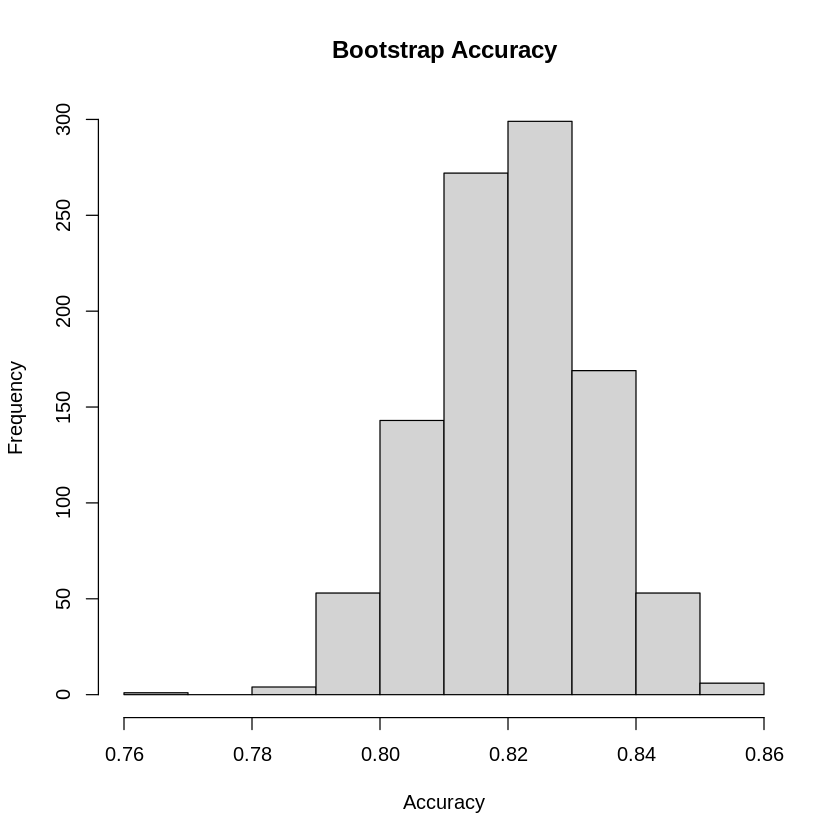

In [19]:
# WRITE YOUR CODE HERE
set.seed(13)

B <- 1000
boot_acc <- rep(NA, B)

n <- nrow(d1)

for (b in 1:B) {

  # resample indices
  idx <- sample(1:n, replace = TRUE)
  d_boot <- d1[idx, ]

  # fit model
  model_b <- glm(Gender ~ FS_Tot_WM_Vol +
                             FS_Total_GM_Vol +
                             FS_IntraCranial_Vol,
                 data = d_boot,
                 family = binomial)

  # predict on bootstrap sample
  probs_b <- predict(model_b, type = "response")

  pred_b <- ifelse(probs_b > 0.5, "M", "F")

  boot_acc[b] <- mean(pred_b == d_boot$Gender)
}

# plot
hist(boot_acc, main = "Bootstrap Accuracy",
     xlab = "Accuracy")

# CI using sd
mean_acc <- mean(boot_acc)
sd_acc <- sd(boot_acc)

CI <- c(mean_acc - 2*sd_acc, mean_acc + 2*sd_acc)

mean_acc
sd_acc
CI


How robust is the prediction accuracy of the full model?

> The bootstrap distribution of accuracy is relatively tight and follows the normal distribution, indicating that the model’s performance is stable. The confidence interval suggests that the prediction accuracy does not vary substantially across samples, meaning the model is fairly robust.
>

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted model) with the distribution of accuracies you get with a randomized grey matter volume term using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

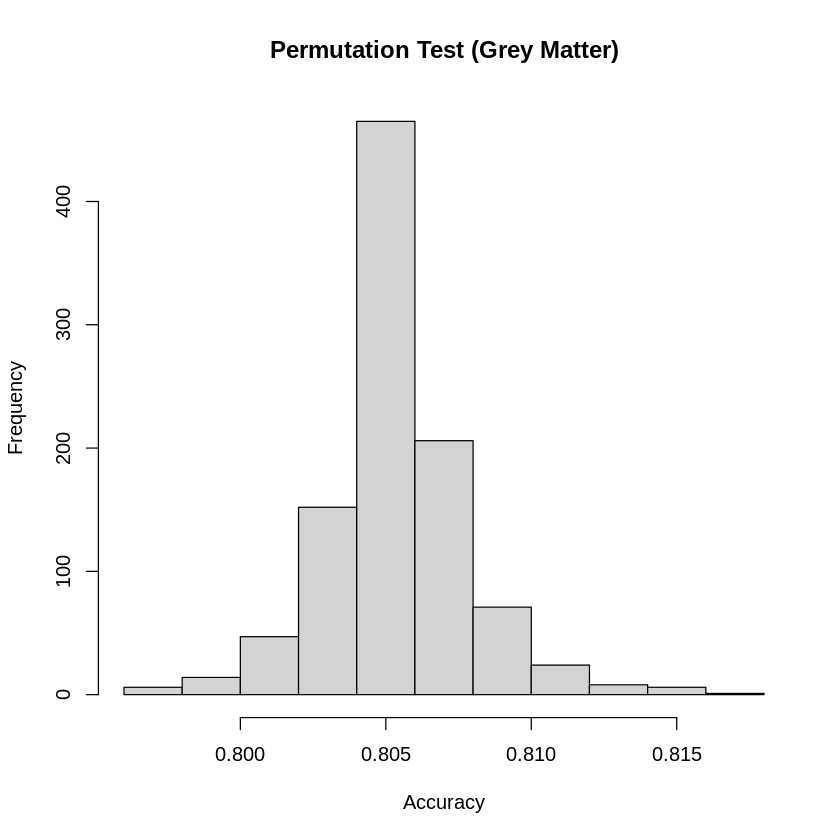

In [20]:
# WRITE YOUR CODE HERE

set.seed(1)

B <- 1000
perm_acc <- rep(NA, B)

# original accuracy
orig_acc <- accuracy

for (b in 1:B) {

  d_perm <- d1

  # permute grey matter
  d_perm$FS_Total_GM_Vol <- sample(d_perm$FS_Total_GM_Vol)

  model_p <- glm(Gender ~ FS_Tot_WM_Vol +
                              FS_Total_GM_Vol +
                              FS_IntraCranial_Vol,
                 data = d_perm,
                 family = binomial)

  probs_p <- predict(model_p, type = "response")

  pred_p <- ifelse(probs_p > 0.5, "M", "F")

  perm_acc[b] <- mean(pred_p == d_perm$Gender)
}

# plot
hist(perm_acc,
     main = "Permutation Test (Grey Matter)",
     xlab = "Accuracy")

abline(v = orig_acc, col = "red", lwd = 2)

How much does the grey matter volume influence the prediction accuracy of the model?

> The original model accuracy is higher than most of the permuted accuracies, indicating that grey matter volume contributes meaningfully to predicting gender. When grey matter is randomized, model performance drops, suggesting that this variable contains important predictive information.
>

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and when is it appropriate to each.

> The bootstrap resamples the data with replacement to estimate the variability of a statistic, such as standard errors or confidence intervals. It is used when you want to assess uncertainty.

> A permutation test shuffles labels to test whether an observed effect is due to chance. It is used for hypothesis testing and assessing statistical significance.

**DUE:** 5pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*